# Circle STARK — Step-by-Step Example

## What is Circle STARK?

Circle STARK is a variant of the standard STARK proof system that replaces the **multiplicative subgroup** of a prime field with the **circle group** over that field.

### Key Idea

The **circle group** over $\mathbb{F}_p$ (for prime $p \equiv 3 \pmod{4}$) is:
$$C(\mathbb{F}_p) = \{(x, y) \in \mathbb{F}_p^2 \mid x^2 + y^2 = 1\}$$

The group operation is **complex multiplication**:
$$(x_1, y_1) \oplus (x_2, y_2) = (x_1 x_2 - y_1 y_2,\; x_1 y_2 + x_2 y_1) \pmod{p}$$

This is exactly multiplying complex numbers $z_1 \cdot z_2$ on the unit circle!

### Why Circle STARK?

| | Standard STARK | Circle STARK |
|---|---|---|
| Domain | Multiplicative subgroup $G \subset \mathbb{F}_p^*$ | Circle subgroup $H \subset C(\mathbb{F}_p)$ |
| Group size | Divisor of $p-1$ | Exactly $p+1$ |
| Best prime | $p = k \cdot 2^n + 1$ (e.g. Goldilocks) | $p = 2^n - 1$ (Mersenne, e.g. $M_{31}$) |
| FFT domain size | $p - 1$ must have large power-of-2 factor | $p + 1$ is exactly a power of 2 (for $M_{31}$) |

For **$M_{31} = 2^{31} - 1$** (Mersenne prime): $|C(\mathbb{F}_{M_{31}})| = 2^{31}$ — a perfect power of 2! This makes Circle STARK extremely efficient in practice.

In this notebook we use $p = 31$ (a toy example) where $|C(\mathbb{F}_{31})| = 32 = 2^5$.

In [18]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from merkle import MerkleTree, verify_decommitment  # StarkWare Merkle tree

# 1. The Circle Group

## 1.1 Setup

In [19]:
# Prime p = 31.  Check: 31 mod 4 = 3, so p ≡ 3 (mod 4) ✓
p = 31
assert p % 4 == 3, "Need p ≡ 3 (mod 4) for |C(F_p)| = p+1"
GROUP_ORDER = p + 1  # = 32 = 2^5

print(f"Prime p = {p}")
print(f"p mod 4 = {p % 4}  →  p ≡ 3 (mod 4) ✓")
print(f"|C(F_p)| = p+1 = {GROUP_ORDER} = 2^{int(np.log2(GROUP_ORDER))}")

Prime p = 31
p mod 4 = 3  →  p ≡ 3 (mod 4) ✓
|C(F_p)| = p+1 = 32 = 2^5


## 1.2 Circle Group Arithmetic

In [20]:
def c_mul(P, Q):
    """Circle group multiplication: (a,b)*(c,d) = (ac-bd, ad+bc) mod p.
    Think of it as complex multiplication: (a+ib)(c+id) mod p."""
    return ((P[0]*Q[0] - P[1]*Q[1]) % p,
            (P[0]*Q[1] + P[1]*Q[0]) % p)

def c_inv(P):
    """Inverse of (x,y) in the circle group = (x,-y) mod p."""
    return (P[0], (-P[1]) % p)

def c_pow(P, n):
    """Compute P^n in the circle group (fast exponentiation)."""
    result = (1, 0)   # identity element
    base   = P
    while n > 0:
        if n & 1:
            result = c_mul(result, base)
        base = c_mul(base, base)
        n >>= 1
    return result

# Quick sanity checks
P = (2, 11)
print(f"Identity check:  P * P^(-1) = {c_mul(P, c_inv(P))}  (should be (1,0))")
print(f"On the circle:   2^2 + 11^2 = {(2**2 + 11**2) % p}  (should be 1)")

Identity check:  P * P^(-1) = (1, 0)  (should be (1,0))
On the circle:   2^2 + 11^2 = 1  (should be 1)


## 1.3 Enumerate All Circle Group Points

Found 32 circle points  (expected p+1 = 32)


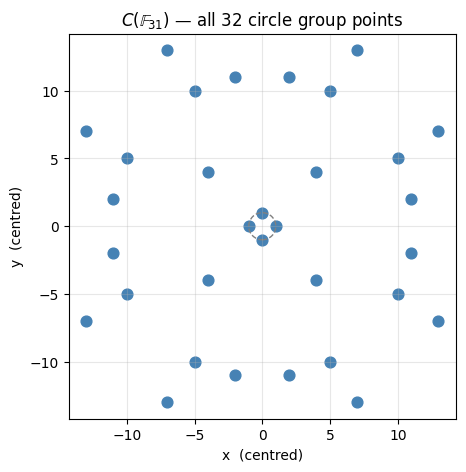

In [21]:
# For p ≡ 3 (mod 4): sqrt(a) mod p = a^((p+1)/4) mod p  (Fermat)
def sqrt_mod(a):
    r = pow(a, (p + 1) // 4, p)
    return r if (r * r) % p == a % p else None

# All (x,y) with x^2 + y^2 = 1 mod p
circle_pts = []
for x in range(p):
    y2 = (1 - x*x) % p
    y  = sqrt_mod(y2)
    if y is not None:
        circle_pts.append((x, y))
        if y != 0:
            circle_pts.append((x, p - y))   # the conjugate (x, -y)

print(f"Found {len(circle_pts)} circle points  (expected p+1 = {GROUP_ORDER})")

# Plot all circle points
xs = [q[0] if q[0] <= p//2 else q[0]-p for q in circle_pts]   # centre around 0
ys = [q[1] if q[1] <= p//2 else q[1]-p for q in circle_pts]
plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=60, color='steelblue')
circle_draw = plt.Circle((0, 0), np.sqrt(xs[0]**2 + ys[0]**2),
                          fill=False, color='gray', linewidth=1, linestyle='--')
plt.gca().add_patch(circle_draw)
plt.title(r'$C(\mathbb{F}_{31})$ — all 32 circle group points')
plt.xlabel('x  (centred)'); plt.ylabel('y  (centred)')
plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.show()

## 1.4 Find a Generator of the Full Circle Group

In [22]:
# A generator g of C(F_p) has order p+1 = 32 = 2^5.
# Test: g is a generator iff g^(GROUP_ORDER/2) != identity.
g = None
for pt in circle_pts:
    if pt == (1, 0):  # skip the identity
        continue
    if c_pow(pt, GROUP_ORDER // 2) != (1, 0):
        g = pt
        break

print(f"Generator g = {g}")
print(f"Verify: g^{GROUP_ORDER} = {c_pow(g, GROUP_ORDER)}  (should be (1,0))")
print(f"Verify: g^{GROUP_ORDER//2} = {c_pow(g, GROUP_ORDER//2)}  (should NOT be (1,0))")

# Build the full evaluation domain  D = {g^0, g^1, ..., g^31}
D = [c_pow(g, k) for k in range(GROUP_ORDER)]
print(f"\nEvaluation domain D  (first 8 of {len(D)} points):")
for k in range(8):
    print(f"  g^{k:2d} = {D[k]}")
print("  ...")

Generator g = (2, 20)
Verify: g^32 = (1, 0)  (should be (1,0))
Verify: g^16 = (30, 0)  (should NOT be (1,0))

Evaluation domain D  (first 8 of 32 points):
  g^ 0 = (1, 0)
  g^ 1 = (2, 20)
  g^ 2 = (7, 18)
  g^ 3 = (26, 21)
  g^ 4 = (4, 4)
  g^ 5 = (21, 26)
  g^ 6 = (18, 7)
  g^ 7 = (20, 2)
  ...


# 2. Trace Domain and Computational Trace

## 2.1 Trace Domain — a Subgroup of the Circle Group

Just as standard STARKs use an $N$-element *multiplicative* subgroup as the trace domain, Circle STARKs use an $N$-element *circle* subgroup.

For $N = 4$, the generator is $h = g^{32/4} = g^8$, giving:
$$H = \{h^0, h^1, h^2, h^3\}$$

In [23]:
N = 4   # trace length — must be a power of 2 and divide GROUP_ORDER
assert (GROUP_ORDER % N == 0) and (N & (N-1)) == 0, "N must be a power-of-2 divisor of GROUP_ORDER"

# Generator of the order-N subgroup
h = c_pow(g, GROUP_ORDER // N)
print(f"Subgroup generator h = g^{GROUP_ORDER//N} = {h}")

# Trace domain
H = [c_pow(h, k) for k in range(N)]
print(f"\nTrace domain H (order-{N} subgroup):")
for k, P in enumerate(H):
    print(f"  H[{k}] = h^{k} = {P}")

# Sanity: h^N = identity
print(f"\nh^{N} = {c_pow(h, N)}  (should be (1,0) ✓)")

# Index of H inside D
H_set      = set(H)
H_idx_in_D = [k for k, P in enumerate(D) if P in H_set]
print(f"\nH points live at D-indices: {H_idx_in_D}")

Subgroup generator h = g^8 = (0, 1)

Trace domain H (order-4 subgroup):
  H[0] = h^0 = (1, 0)
  H[1] = h^1 = (0, 1)
  H[2] = h^2 = (30, 0)
  H[3] = h^3 = (0, 30)

h^4 = (1, 0)  (should be (1,0) ✓)

H points live at D-indices: [0, 8, 16, 24]


## 2.2 Define the Computational Trace

We want to **prove** that a sequence $A$ contains only binary values (0 or 1).

The **polynomial constraint** for binary traces is:
$$A[i]^2 - A[i] = 0 \quad \text{for all } i$$
because $a^2 - a = a(a-1) = 0$ if and only if $a \in \{0, 1\}$.

In [24]:
np.random.seed(5)
A = list(np.random.randint(low=0, high=2, size=N))

print(f"Trace A = {A}")
print(f"Length N = {len(A)}")
print(f"All values binary: {all(a in [0, 1] for a in A)} ✓")
print(f"\nTrace values at circle subgroup H:")
for k, (P, a) in enumerate(zip(H, A)):
    print(f"  f(H[{k}]) = f({P}) = {a}")

Trace A = [np.int64(1), np.int64(0), np.int64(1), np.int64(1)]
Length N = 4
All values binary: True ✓

Trace values at circle subgroup H:
  f(H[0]) = f((1, 0)) = 1
  f(H[1]) = f((0, 1)) = 0
  f(H[2]) = f((30, 0)) = 1
  f(H[3]) = f((0, 30)) = 1


# 3. Polynomial Interpolation on the Circle

## 3.1 Circle-Adapted Lagrange Interpolation

In standard STARK, the trace polynomial is found by interpolating over the subgroup $G$ (roots of unity) using the standard polynomial basis.

In Circle STARK, we interpolate over the circle subgroup $H$ using a **circle-adapted basis**.

**Key ingredient**: For a circle point $Q = (x_0, y_0)$, the linear form
$$\ell_Q(x, y) = x \cdot x_0 + y \cdot y_0 - 1$$
vanishes **only** at $Q$ among all circle points, because:
$$\ell_Q(x, y) = 0 \iff (x - x_0)^2 + (y - y_0)^2 = 0 \iff (x, y) = (x_0, y_0)$$
(using $x^2+y^2 = 1$ and $x_0^2+y_0^2 = 1$)

The **circle Lagrange basis function** for the $i$-th point in $H$ is:
$$L_i(x, y) = \prod_{j \neq i} \ell_{H[j]}(x,y) \;\Big/\; \prod_{j \neq i} \ell_{H[j]}(H[i])$$

In [25]:
def circle_linear_form(Q, P):
    """l_Q(P) = P.x*Q.x + P.y*Q.y - 1  (vanishes only at Q on the circle)."""
    return (P[0]*Q[0] + P[1]*Q[1] - 1) % p

def lagrange_eval(H_pts, vals, P):
    """Evaluate the unique interpolating polynomial at P using circle Lagrange basis."""
    result = 0
    for i, (Pi, vi) in enumerate(zip(H_pts, vals)):
        # numerator:   product of l_{H[j]}(P) for j ≠ i
        # denominator: product of l_{H[j]}(Pi) for j ≠ i
        num   = 1
        denom = 1
        for j, Pj in enumerate(H_pts):
            if j != i:
                num   = (num   * circle_linear_form(Pj, P )) % p
                denom = (denom * circle_linear_form(Pj, Pi)) % p
        denom_inv = pow(int(denom), p - 2, p)     # modular inverse (Fermat)
        Li_P = (num * denom_inv) % p
        result = (result + vi * Li_P) % p
    return result

# Verify: f(H[i]) must equal A[i]
print("Verifying circle Lagrange interpolation:")
for i, (Pi, Ai) in enumerate(zip(H, A)):
    f_Pi = lagrange_eval(H, A, Pi)
    check = "✓" if f_Pi == Ai else "✗"
    print(f"  f(H[{i}]) = f({Pi}) = {f_Pi}   (trace A[{i}] = {Ai}) {check}")

Verifying circle Lagrange interpolation:
  f(H[0]) = f((1, 0)) = 1   (trace A[0] = 1) ✓
  f(H[1]) = f((0, 1)) = 0   (trace A[1] = 0) ✓
  f(H[2]) = f((30, 0)) = 1   (trace A[2] = 1) ✓
  f(H[3]) = f((0, 30)) = 1   (trace A[3] = 1) ✓


# 4. Evaluate the Polynomial on a Larger Domain

Just as in standard STARK, the prover evaluates the trace polynomial on a **blowup** domain $D$ that is much larger than $H$. Here we use the full circle group $D = C(\mathbb{F}_{31})$ of size 32.

Evaluating f on D (this uses O(N·|D|) circle linear forms)...
f on D = [np.int64(1), np.int64(17), np.int64(23), np.int64(17), np.int64(23), np.int64(20), np.int64(22), np.int64(26), np.int64(0), np.int64(26), np.int64(22), np.int64(20), np.int64(23), np.int64(17), np.int64(23), np.int64(17), np.int64(1), np.int64(19), np.int64(27), np.int64(9), np.int64(25), np.int64(19), np.int64(24), np.int64(3), np.int64(1), np.int64(3), np.int64(24), np.int64(19), np.int64(25), np.int64(9), np.int64(27), np.int64(19)]

f on H (should equal A = [np.int64(1), np.int64(0), np.int64(1), np.int64(1)]):  [np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


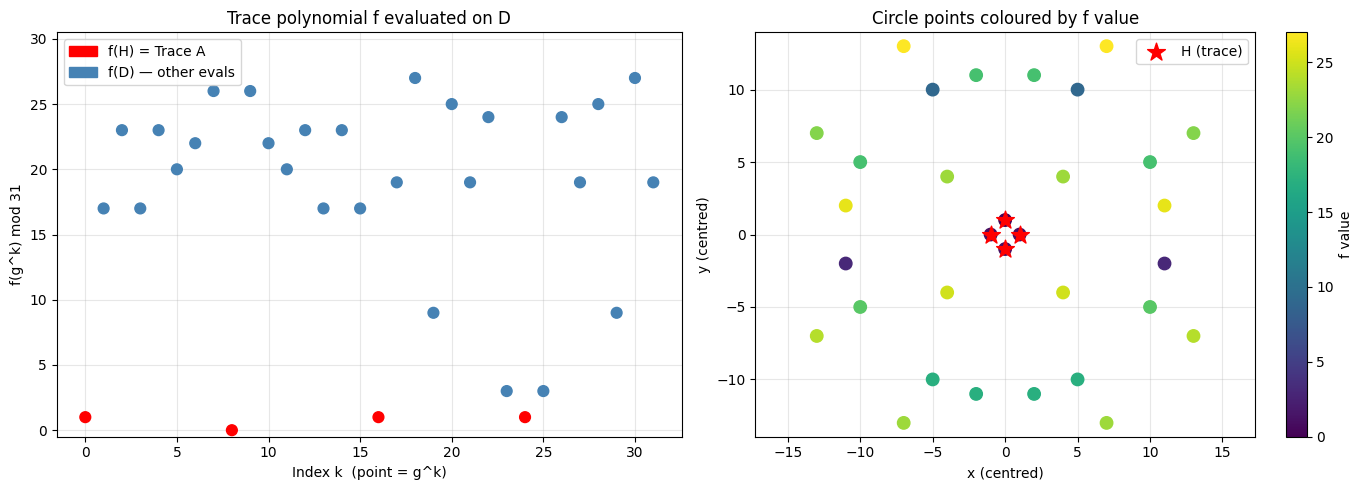

In [26]:
# Evaluate f on all 32 points of D
print("Evaluating f on D (this uses O(N·|D|) circle linear forms)...")
f_D = [lagrange_eval(H, A, P) for P in D]

print(f"f on D = {f_D}")
print(f"\nf on H (should equal A = {A}):  {[f_D[k] for k in H_idx_in_D]}")

# --- Plot ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: f values vs index
ax = axes[0]
colours = ['red' if k in H_idx_in_D else 'steelblue' for k in range(GROUP_ORDER)]
ax.scatter(range(GROUP_ORDER), f_D, c=colours, s=60, zorder=3)
ax.set_title('Trace polynomial f evaluated on D')
ax.set_xlabel('Index k  (point = g^k)')
ax.set_ylabel('f(g^k) mod 31')
ax.set_ylim(-0.5, p - 0.5)
red_patch  = mpatches.Patch(color='red',       label='f(H) = Trace A')
blue_patch = mpatches.Patch(color='steelblue', label='f(D) — other evals')
ax.legend(handles=[red_patch, blue_patch])
ax.grid(True, alpha=0.3)

# Right: circle points coloured by f value
ax2 = axes[1]
xs_c = [P[0] if P[0] <= p//2 else P[0]-p for P in D]
ys_c = [P[1] if P[1] <= p//2 else P[1]-p for P in D]
sc = ax2.scatter(xs_c, ys_c, c=f_D, cmap='viridis', s=80, zorder=3)
plt.colorbar(sc, ax=ax2, label='f value')
H_xs = [P[0] if P[0] <= p//2 else P[0]-p for P in H]
H_ys = [P[1] if P[1] <= p//2 else P[1]-p for P in H]
ax2.scatter(H_xs, H_ys, c='red', s=180, marker='*', zorder=5, label='H (trace)')
ax2.set_title('Circle points coloured by f value')
ax2.set_xlabel('x (centred)'); ax2.set_ylabel('y (centred)')
ax2.legend(); ax2.axis('equal'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Apply the Polynomial Constraint

The **binary constraint** states:
$$c(P) = f(P)^2 - f(P) = 0 \quad \text{for all } P \in H$$

This is the arithmetic encoding of "$f(P)$ is either 0 or 1".

Constraint c(f(P)) = f(P)^2 - f(P) on trace domain H:
  c(f(g^ 0)) = c(1) = 0  ✓
  c(f(g^ 8)) = c(0) = 0  ✓
  c(f(g^16)) = c(1) = 0  ✓
  c(f(g^24)) = c(1) = 0  ✓

All constraint values are 0 on H  →  the trace is a valid binary sequence ✓


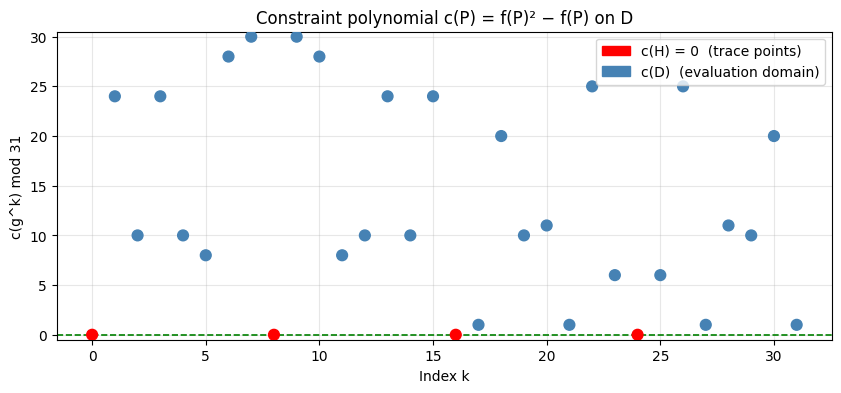

In [27]:
def constraint(v):
    """Binary constraint: c(v) = v^2 - v  (= 0 iff v ∈ {0,1})"""
    return (v * v - v) % p

# Evaluate constraint on every D point
c_D = [constraint(fv) for fv in f_D]

# Check: should be 0 for all H points
print("Constraint c(f(P)) = f(P)^2 - f(P) on trace domain H:")
for k in H_idx_in_D:
    print(f"  c(f(g^{k:2d})) = c({f_D[k]}) = {c_D[k]}  {'✓' if c_D[k] == 0 else '✗ FAIL'}")

assert all(c_D[k] == 0 for k in H_idx_in_D), "Constraint failed on H!"
print("\nAll constraint values are 0 on H  →  the trace is a valid binary sequence ✓")

# Plot c on D
plt.figure(figsize=(10, 4))
colours = ['red' if k in H_idx_in_D else 'steelblue' for k in range(GROUP_ORDER)]
plt.scatter(range(GROUP_ORDER), c_D, c=colours, s=60, zorder=3)
plt.axhline(0, color='green', linewidth=1.2, linestyle='--', label='0 line')
plt.title('Constraint polynomial c(P) = f(P)² − f(P) on D')
plt.xlabel('Index k'); plt.ylabel('c(g^k) mod 31')
plt.ylim(-0.5, p - 0.5)
red_patch  = mpatches.Patch(color='red',       label='c(H) = 0  (trace points)')
blue_patch = mpatches.Patch(color='steelblue', label='c(D)  (evaluation domain)')
plt.legend(handles=[red_patch, blue_patch])
plt.grid(True, alpha=0.3)
plt.show()

# 6. Vanishing Polynomial for the Circle Subgroup

## 6.1 What is the Vanishing Polynomial?

In standard STARK the vanishing polynomial for $G = \{g^0, \ldots, g^{N-1}\}$ is $x^N - 1$, which is zero exactly on $G$.

In Circle STARK we need a polynomial that is zero **exactly** on $H$.

**Construction**: Use the product of circle linear forms:
$$V_H(x, y) = \prod_{Q \in H} \ell_Q(x, y) = \prod_{Q \in H} (x \cdot Q_x + y \cdot Q_y - 1)$$

Since each $\ell_Q$ vanishes only at $Q$ among circle points, $V_H$ vanishes exactly on $H$.

## 6.2 A Closed Form for $H_4$

For $H_4 = \{(1,0),\,(0,-1),\,(-1,0),\,(0,1)\}$ the product telescopes (on the circle) to:
$$V_{H_4}(x, y) = (xy)^2 \pmod{p}$$

Proof sketch: the four linear forms are $(x-1),\,(-y-1),\,(-x-1),\,(y-1)$; their product on $x^2+y^2=1$ reduces to $x^2 y^2$.

V_H on H (should all be 0):
  V_H(g^ 0) = V_H((1, 0)) = 0  ✓
  V_H(g^ 8) = V_H((0, 1)) = 0  ✓
  V_H(g^16) = V_H((30, 0)) = 0  ✓
  V_H(g^24) = V_H((0, 30)) = 0  ✓

V_H on D\H  (should all be non-zero): all non-zero = True ✓

Cross-check  V_H(P) = (x·y)^2 for all circle points:
  All 32 points match: V_H(x,y) = (xy)^2 ✓


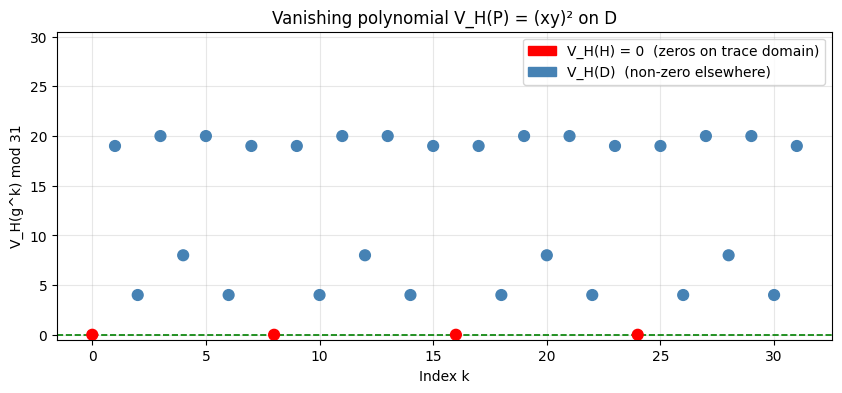

In [28]:
def vanishing_poly(P):
    """V_H(P) = product of l_Q(P) for all Q in H."""
    v = 1
    for Q in H:
        v = (v * circle_linear_form(Q, P)) % p
    return v

# Evaluate V_H on D
V_D = [vanishing_poly(P) for P in D]

# Verify: zero exactly on H, non-zero elsewhere
print("V_H on H (should all be 0):")
for k in H_idx_in_D:
    print(f"  V_H(g^{k:2d}) = V_H({D[k]}) = {V_D[k]}  {'✓' if V_D[k] == 0 else '✗'}")

non_H_idx = [k for k in range(GROUP_ORDER) if k not in H_idx_in_D]
print(f"\nV_H on D\\H  (should all be non-zero): all non-zero = {all(V_D[k] != 0 for k in non_H_idx)} ✓")

# Cross-check: V_H = (xy)^2 on the circle
print("\nCross-check  V_H(P) = (x·y)^2 for all circle points:")
mismatches = 0
for P in D:
    v1 = vanishing_poly(P)
    v2 = (P[0] * P[1])**2 % p
    if v1 != v2:
        mismatches += 1
        print(f"  MISMATCH at {P}: product={v1}, (xy)^2={v2}")
if mismatches == 0:
    print(f"  All 32 points match: V_H(x,y) = (xy)^2 ✓")

# Plot
plt.figure(figsize=(10, 4))
colours = ['red' if k in H_idx_in_D else 'steelblue' for k in range(GROUP_ORDER)]
plt.scatter(range(GROUP_ORDER), V_D, c=colours, s=60, zorder=3)
plt.axhline(0, color='green', linewidth=1.2, linestyle='--', label='0 line')
plt.title('Vanishing polynomial V_H(P) = (xy)² on D')
plt.xlabel('Index k'); plt.ylabel('V_H(g^k) mod 31')
plt.ylim(-0.5, p - 0.5)
red_patch  = mpatches.Patch(color='red',       label='V_H(H) = 0  (zeros on trace domain)')
blue_patch = mpatches.Patch(color='steelblue', label='V_H(D)  (non-zero elsewhere)')
plt.legend(handles=[red_patch, blue_patch])
plt.grid(True, alpha=0.3)
plt.show()

# 7. Quotient (Composition) Polynomial

## 7.1 Idea

Since $c(P) = 0$ for all $P \in H$, and $V_H(P) = 0$ exactly on $H$, the quotient
$$q(P) = \frac{c(P)}{V_H(P)}$$
is a **well-defined polynomial** on $D \setminus H$ (no 0/0 issues at off-H points).

In standard STARK: $p(x) = \dfrac{f(x)^2 - f(x)}{x^N - 1}$

In Circle STARK: $q(P) = \dfrac{f(P)^2 - f(P)}{V_H(P)} = \dfrac{c(P)}{(xy)^2}$

## 7.2 Why Does This Matter?

The **degree** of $q$ is much lower than the degree of $c$.  
A verifier can check that $q$ has bounded degree (via FRI) **without** evaluating $f$ everywhere — this is the core efficiency win of STARKs.

Quotient polynomial q(P) = c(P) / V_H(P) on D \ H:
  q(g^ 1) = q((2, 20)) = 29
  q(g^ 2) = q((7, 18)) = 18
  q(g^ 3) = q((26, 21)) = 26
  q(g^ 4) = q((4, 4)) = 9
  q(g^ 5) = q((21, 26)) = 19
  q(g^ 6) = q((18, 7)) = 7
  q(g^ 7) = q((20, 2)) = 13
  q(g^ 9) = q((11, 2)) = 13
  q(g^10) = q((13, 7)) = 7
  q(g^11) = q((10, 26)) = 19
  q(g^12) = q((27, 4)) = 9
  q(g^13) = q((5, 21)) = 26
  q(g^14) = q((24, 18)) = 18
  q(g^15) = q((29, 20)) = 29
  q(g^17) = q((29, 11)) = 18
  q(g^18) = q((24, 13)) = 5
  q(g^19) = q((5, 10)) = 16
  q(g^20) = q((27, 27)) = 13
  q(g^21) = q((10, 5)) = 14
  q(g^22) = q((13, 24)) = 14
  q(g^23) = q((11, 29)) = 15
  q(g^25) = q((20, 29)) = 15
  q(g^26) = q((18, 24)) = 14
  q(g^27) = q((21, 5)) = 14
  q(g^28) = q((4, 27)) = 13
  q(g^29) = q((26, 10)) = 16
  q(g^30) = q((7, 13)) = 5
  q(g^31) = q((2, 11)) = 18

Distinct values of q: [np.int64(5), np.int64(7), np.int64(9), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(19), np.int64(26)

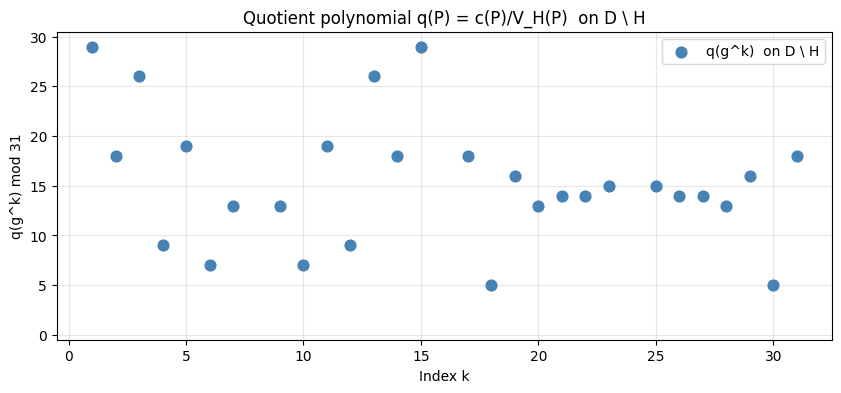

In [29]:
# Compute q(P) = c(P) / V_H(P)  for P in D \ H
q_D = []
for k, (P, cP, vP) in enumerate(zip(D, c_D, V_D)):
    if k in H_idx_in_D:
        q_D.append(None)   # 0/0 at H-points: not evaluated here
    else:
        v_inv = pow(int(vP), p - 2, p)   # 1/V_H(P) in F_p
        q_D.append((cP * v_inv) % p)

non_none_vals = [v for v in q_D if v is not None]
non_none_idx  = [k for k, v in enumerate(q_D) if v is not None]

print("Quotient polynomial q(P) = c(P) / V_H(P) on D \\ H:")
for k in non_none_idx:
    print(f"  q(g^{k:2d}) = q({D[k]}) = {q_D[k]}")

print(f"\nDistinct values of q: {sorted(set(non_none_vals))}")
print(f"Looks like a low-degree (possibly constant) polynomial ✓")

# Plot
plt.figure(figsize=(10, 4))
plt.scatter(non_none_idx, non_none_vals, s=60, color='steelblue', zorder=3,
            label='q(g^k)  on D \\ H')
plt.title('Quotient polynomial q(P) = c(P)/V_H(P)  on D \\ H')
plt.xlabel('Index k'); plt.ylabel('q(g^k) mod 31')
plt.ylim(-0.5, p - 0.5)
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# 8. Commitments

## 8.1 Simple Merkle Tree

The prover commits to the evaluation vectors $f(D)$ and $q(D \setminus H)$ using Merkle trees so the verifier can later request individual leaves with short authentication paths.

In [30]:
# MerkleTree and verify_decommitment are imported from merkle.py (StarkWare)
# at the top of the notebook.  Nothing to define here.
print('MerkleTree and verify_decommitment ready (StarkWare merkle.py) ✓')

MerkleTree and verify_decommitment ready (StarkWare merkle.py) ✓


## 8.2 Prover Commits

In [31]:
# Build Merkle trees for f(D) and q(D)
q_D_for_commit = [v if v is not None else 0 for v in q_D]   # use 0 as placeholder at H

MT_f = MerkleTree(f_D)
MT_q = MerkleTree(q_D_for_commit)

root_f = MT_f.root
root_q = MT_q.root

print("Prover sends Merkle root of f(D) to verifier:")
print(f"  root_f = {root_f}")
print()
print("Prover sends Merkle root of q(D) to verifier:")
print(f"  root_q = {root_q}")
print()
print(f"Leaves of f(D):  {f_D}")
print(f"Leaves of q(D):  {q_D_for_commit}")

Prover sends Merkle root of f(D) to verifier:
  root_f = bf0da2d43f9b6c736caff87e72c41ecaf0630fd112ebbd76f8289a7ab1a6b9b1

Prover sends Merkle root of q(D) to verifier:
  root_q = 27a7cad1c39fef3d7a8d88157ba392eeaf1401964a430e8c13e5c64aecab43fa

Leaves of f(D):  [np.int64(1), np.int64(17), np.int64(23), np.int64(17), np.int64(23), np.int64(20), np.int64(22), np.int64(26), np.int64(0), np.int64(26), np.int64(22), np.int64(20), np.int64(23), np.int64(17), np.int64(23), np.int64(17), np.int64(1), np.int64(19), np.int64(27), np.int64(9), np.int64(25), np.int64(19), np.int64(24), np.int64(3), np.int64(1), np.int64(3), np.int64(24), np.int64(19), np.int64(25), np.int64(9), np.int64(27), np.int64(19)]
Leaves of q(D):  [0, np.int64(29), np.int64(18), np.int64(26), np.int64(9), np.int64(19), np.int64(7), np.int64(13), 0, np.int64(13), np.int64(7), np.int64(19), np.int64(9), np.int64(26), np.int64(18), np.int64(29), 0, np.int64(18), np.int64(5), np.int64(16), np.int64(13), np.int64(14), np.int64

## 8.3 Verifier Queries

The verifier picks random positions $z \in D \setminus H$ and checks:

1. **Equation**: $q(z) \cdot V_H(z) = c(f(z)) = f(z)^2 - f(z)$
2. **Commitment**: the claimed $f(z)$ and $q(z)$ open correctly against $\text{root}_f$ and $\text{root}_q$

These two checks together convince the verifier (with high probability) that the trace polynomial $f$ satisfies the binary constraint on all of $H$.

In [32]:
# Verifier picks 3 random query indices from D \ H
np.random.seed(42)
num_queries = 3
query_pool  = [k for k in range(GROUP_ORDER) if k not in H_idx_in_D]
queries     = list(np.random.choice(query_pool, num_queries, replace=False))
print(f"Verifier queries at D-indices: {queries}\n")

all_pass = True
for qi in queries:
    P      = D[qi]
    fP     = f_D[qi]
    qP     = q_D_for_commit[qi]
    vP     = V_D[qi]
    path_f = MT_f.get_authentication_path(qi)
    path_q = MT_q.get_authentication_path(qi)

    print(f"--- Query at g^{qi} = {P} ---")
    print(f"  Prover sends:  f({P}) = {fP},   q({P}) = {qP}")

    # Check (i): q(P) * V_H(P) == f(P)^2 - f(P)   (mod p)
    lhs = (qP * vP) % p
    rhs = (fP * fP - fP) % p
    eq_ok = (lhs == rhs)
    print(f"  (i)  q·V_H = {lhs},   f²-f = {rhs}   {'✓' if eq_ok else '✗ FAIL'}")

    # Check (ii): Merkle decommitments
    open_f = verify_decommitment(qi, fP, path_f, root_f)
    open_q = verify_decommitment(qi, qP, path_q, root_q)
    print(f"  (ii) f decommitment: {'✓' if open_f else '✗ FAIL'} | q decommitment: {'✓' if open_q else '✗ FAIL'}")

    if not (eq_ok and open_f and open_q):
        all_pass = False
    print()

print("="*40)
print(f"Overall: {'PROOF ACCEPTED ✓' if all_pass else 'PROOF REJECTED ✗'}")

Verifier queries at D-indices: [np.int64(11), np.int64(29), np.int64(10)]

--- Query at g^11 = (10, 26) ---
  Prover sends:  f((10, 26)) = 20,   q((10, 26)) = 19
  (i)  q·V_H = 8,   f²-f = 8   ✓
  (ii) f decommitment: ✓ | q decommitment: ✓

--- Query at g^29 = (26, 10) ---
  Prover sends:  f((26, 10)) = 9,   q((26, 10)) = 16
  (i)  q·V_H = 10,   f²-f = 10   ✓
  (ii) f decommitment: ✓ | q decommitment: ✓

--- Query at g^10 = (13, 7) ---
  Prover sends:  f((13, 7)) = 22,   q((13, 7)) = 7
  (i)  q·V_H = 28,   f²-f = 28   ✓
  (ii) f decommitment: ✓ | q decommitment: ✓

Overall: PROOF ACCEPTED ✓


# 9. Summary — Standard STARK vs Circle STARK

| Step | Standard STARK | Circle STARK (this notebook) |
|---|---|---|
| **Field** | $\mathbb{F}_p$, prime $p \equiv 1 \pmod{2^n}$ | $\mathbb{F}_p$, prime $p \equiv 3 \pmod{4}$ |
| **Trace domain** | Multiplicative subgroup $G \subset \mathbb{F}_p^*$ | Circle subgroup $H \subset C(\mathbb{F}_p)$ |
| **Group size** | Divides $p-1$ | Exactly $p+1$ |
| **Ideal prime** | $p = k \cdot 2^n + 1$ (Goldilocks, BabyBear) | $p = 2^n - 1$ (Mersenne $M_{31}$) |
| **Polynomial basis** | Monomials $1, x, x^2, \ldots$ | Circle forms $\ell_Q(x,y) = x Q_x + y Q_y - 1$ |
| **Vanishing poly** | $x^N - 1$ | $V_H(x,y) = \prod_{Q \in H} \ell_Q(x,y) = (xy)^2$ (for $N=4$) |
| **Constraint** | $f(x)^2 - f(x) = 0$ on $G$ | $f(P)^2 - f(P) = 0$ on $H$ |
| **Quotient** | $p(x) = \frac{f^2-f}{x^N-1}$ | $q(P) = \frac{f(P)^2-f(P)}{V_H(P)}$ |
| **Commitment** | Merkle tree of $f(L)$, $p(L)$ | Merkle tree of $f(D)$, $q(D)$ |

**Key advantage of Circle STARK**: For $M_{31} = 2^{31}-1$, the circle group has order exactly $2^{31}$. This means:
- No wasted field elements (unlike $p-1$ which may have small power-of-2 factors)
- Maximum FFT efficiency with no padding
- The Circle FFT (CFFT) can be implemented very efficiently using the doubling map $(x,y) \mapsto (2x^2-1, 2xy)$